In [3]:
import numpy as np
import random
import datetime
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import math
import pandas as pd
import os
import matplotlib.pyplot as plt
import joblib

random.seed(42)
np.random.seed(42)


ModuleNotFoundError: No module named 'numpy'

In [208]:
# Load FINAL model
model = load_model("../models/densenet121_final.h5")
print("Final model loaded successfully.")

forecast_model = joblib.load("../models/fill_forecast_rf.pkl")
print("Forecast model loaded.")

Final model loaded successfully.
Forecast model loaded.


In [209]:
DATASET_DIR = "../data/images"
IMG_SIZE = (224, 224)

datagen = ImageDataGenerator(rescale=1./255)

generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=1,
    class_mode="categorical",
    shuffle=False
)

class_names = list(generator.class_indices.keys())

print("Classes:", class_names)


Found 2527 images belonging to 6 classes.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [210]:
def simulate_iot_data(bin_id):
    return {
        "bin_id": bin_id,
        "fill_level": random.randint(10, 100),  # percentage
        "location": f"Sector {random.choice(['A', 'B', 'C'])}",
        "last_collection_hours": random.randint(1, 48),
        "timestamp": datetime.datetime.now()
    }


In [211]:
def predict_future_fill(current_fill, hour, day, weekend=0):
    import pandas as pd
    input_data = pd.DataFrame([{
        "fill_level": current_fill,
        "hour_of_day": hour,
        "day": day,
        "weekend": weekend
    }])
    return float(forecast_model.predict(input_data)[0])


In [212]:
def calculate_priority_score(confidence, bin_data):

    predicted_fill = predict_future_fill(
        current_fill=bin_data["fill_level"],
        hour=datetime.datetime.now().hour,
        day=0
    )

    fill_weight = 0.5
    time_weight = 0.3
    confidence_weight = 0.2

    fill_score = predicted_fill / 100
    time_score = bin_data["last_collection_hours"] / 48
    confidence_score = 1 - confidence

    priority_score = (
        fill_weight * fill_score +
        time_weight * time_score +
        confidence_weight * confidence_score
    )

    return round(priority_score, 2), round(predicted_fill, 1)


In [213]:
def process_bin(bin_id, img_path):

    from tensorflow.keras.preprocessing import image

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_class = class_names[np.argmax(pred)]
    confidence = float(np.max(pred))

    bin_data = simulate_iot_data(bin_id)

    priority_score, predicted_fill = calculate_priority_score(confidence, bin_data)

    return {
        "bin_id": bin_id,
    "waste_type": pred_class,
    "confidence": round(confidence, 2),
    "fill_level": bin_data["fill_level"],
    "predicted_fill": predicted_fill,
    "location": bin_data["location"],
    "last_collection_hours": bin_data["last_collection_hours"],
    "priority_score": priority_score
    }


In [214]:
test_image = "../data/images/plastic/plastic32.jpg"

bins = ["BIN_101", "BIN_102", "BIN_103"]

results = []

for b in bins:
    results.append(process_bin(b, test_image))

# Sort by priority score (highest first)
results = sorted(results, key=lambda x: x["priority_score"], reverse=True)

for r in results:
    print("\n--- Smart Bin Priority Report ---")
    for k, v in r.items():
        print(f"{k}: {v}")



1/1 [==============================] - 0s 142ms/step

--- Smart Bin Priority Report ---
bin_id: BIN_101
waste_type: plastic
confidence: 1.0
fill_level: 51
predicted_fill: 56.5
location: Sector A
last_collection_hours: 15
priority_score: 0.38

--- Smart Bin Priority Report ---
bin_id: BIN_103
waste_type: plastic
confidence: 1.0
fill_level: 44
predicted_fill: 50.3
location: Sector A
last_collection_hours: 14
priority_score: 0.34

--- Smart Bin Priority Report ---
bin_id: BIN_102
waste_type: plastic
confidence: 1.0
fill_level: 14
predicted_fill: 22.8
location: Sector B
last_collection_hours: 26
priority_score: 0.28


In [215]:
# Use the already-built results as routing input
reports = results.copy()

print("Routing input bins:", len(reports))
print(reports[0])


Routing input bins: 3
{'bin_id': 'BIN_101', 'waste_type': 'plastic', 'confidence': 1.0, 'fill_level': 51, 'predicted_fill': 56.5, 'location': 'Sector A', 'last_collection_hours': 15, 'priority_score': 0.38}


In [216]:
# Build a list of random images from dataset folders
image_paths = []
for cls in class_names:
    cls_dir = os.path.join(DATASET_DIR, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(cls_dir, f))

print("Total images found:", len(image_paths))

# Create 10 bins and process each with a random image
bins = [f"BIN_{101+i}" for i in range(10)]
results = []

for b in bins:
    img_path = random.choice(image_paths)
    results.append(process_bin(b, img_path))

# Sort by priority (highest first)
results = sorted(results, key=lambda x: x["priority_score"], reverse=True)

print("Generated smart bin reports:", len(results))
print(results[0])

Total images found: 2527
1/1 [==============================] - 0s 160ms/step
Generated smart bin reports: 10
{'bin_id': 'BIN_108', 'waste_type': 'glass', 'confidence': 0.96, 'fill_level': 90, 'predicted_fill': 98.8, 'location': 'Sector A', 'last_collection_hours': 44, 'priority_score': 0.78}


In [217]:
# Example depot location (Hull)
DEPOT = (53.7708, -0.3672)

# Give each sector a base coordinate
sector_coords = {
    "Sector A": (53.76, -0.36),
    "Sector B": (53.77, -0.38),
    "Sector C": (53.75, -0.37)
}

for r in results:
    base = sector_coords[r["location"]]
    # small random noise to make each bin unique
    r["coordinates"] = (
        base[0] + random.uniform(-0.01, 0.01),
        base[1] + random.uniform(-0.01, 0.01)
    )

reports = results.copy()
print("Coordinates assigned.")
print(reports[0])


Coordinates assigned.
{'bin_id': 'BIN_108', 'waste_type': 'glass', 'confidence': 0.96, 'fill_level': 90, 'predicted_fill': 98.8, 'location': 'Sector A', 'last_collection_hours': 44, 'priority_score': 0.78, 'coordinates': (53.755028282399635, -0.35893548207569426)}


In [218]:
def haversine(coord1, coord2):
    R = 6371  # km
    lat1, lon1 = coord1
    lat2, lon2 = coord2

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c


In [219]:
remaining = reports.copy()
current = DEPOT
route = []
total_distance = 0

while remaining:
    scored = []
    for b in remaining:
        dist = haversine(current, b["coordinates"])
        # weighted by priority (higher priority reduces score)
        score = dist / (b["priority_score"] + 0.01)
        scored.append((score, dist, b))

    scored.sort(key=lambda x: x[0])
    chosen_score, chosen_dist, chosen_bin = scored[0]

    route.append(chosen_bin)
    total_distance += chosen_dist
    current = chosen_bin["coordinates"]
    remaining.remove(chosen_bin)

print("\n--- Optimised Collection Route (Priority + Distance) ---")
for i, b in enumerate(route, 1):
    print(f"{i}. {b['bin_id']} | {b['location']} | Fill={b['fill_level']}% | Priority={b['priority_score']}")

print("\nTotal Travel Distance (km):", round(total_distance, 2))



--- Optimised Collection Route (Priority + Distance) ---
1. BIN_110 | Sector B | Fill=86% | Priority=0.68
2. BIN_108 | Sector A | Fill=90% | Priority=0.78
3. BIN_106 | Sector A | Fill=38% | Priority=0.42
4. BIN_102 | Sector C | Fill=60% | Priority=0.46
5. BIN_105 | Sector C | Fill=64% | Priority=0.35
6. BIN_109 | Sector A | Fill=86% | Priority=0.62
7. BIN_101 | Sector A | Fill=50% | Priority=0.41
8. BIN_103 | Sector A | Fill=43% | Priority=0.4
9. BIN_104 | Sector B | Fill=78% | Priority=0.68
10. BIN_107 | Sector A | Fill=21% | Priority=0.16

Total Travel Distance (km): 11.19


In [220]:
TRUCK_CAPACITY = 300

current = DEPOT
current_load = 0
total_distance_capacity = 0

remaining = reports.copy()

trip_number = 1
trip_bins = []
all_trips = []

while remaining:
    feasible = [b for b in remaining if current_load + b["fill_level"] <= TRUCK_CAPACITY]

    # If no feasible bins, close trip (return depot)
    if not feasible:
        total_distance_capacity += haversine(current, DEPOT)
        all_trips.append({
            "trip": trip_number,
            "bins": trip_bins,
            "load": current_load
        })

        # Reset for next trip
        trip_number += 1
        trip_bins = []
        current = DEPOT
        current_load = 0
        continue

    # Choose next bin using priority + distance score
    scored = []
    for b in feasible:
        dist = haversine(current, b["coordinates"])
        score = dist / (b["priority_score"] + 0.01)
        scored.append((score, dist, b))

    scored.sort(key=lambda x: x[0])
    _, dist, chosen = scored[0]

    trip_bins.append(chosen)
    total_distance_capacity += dist
    current = chosen["coordinates"]
    current_load += chosen["fill_level"]
    remaining.remove(chosen)

# Close last trip
total_distance_capacity += haversine(current, DEPOT)
all_trips.append({
    "trip": trip_number,
    "bins": trip_bins,
    "load": current_load
})

print("\n--- Capacity-Constrained Collection Plan ---")
for t in all_trips:
    print(f"\nTrip {t['trip']} | Load used: {t['load']}/{TRUCK_CAPACITY}")
    for i, b in enumerate(t["bins"], 1):
        print(f"  {i}. {b['bin_id']} | {b['location']} | Fill={b['fill_level']}% | Priority={b['priority_score']}")

print("\nTotal Trips:", len(all_trips))
print("Total Travel Distance (km):", round(total_distance_capacity, 2))



--- Capacity-Constrained Collection Plan ---

Trip 1 | Load used: 295/300
  1. BIN_110 | Sector B | Fill=86% | Priority=0.68
  2. BIN_108 | Sector A | Fill=90% | Priority=0.78
  3. BIN_106 | Sector A | Fill=38% | Priority=0.42
  4. BIN_102 | Sector C | Fill=60% | Priority=0.46
  5. BIN_107 | Sector A | Fill=21% | Priority=0.16

Trip 2 | Load used: 257/300
  1. BIN_104 | Sector B | Fill=78% | Priority=0.68
  2. BIN_109 | Sector A | Fill=86% | Priority=0.62
  3. BIN_101 | Sector A | Fill=50% | Priority=0.41
  4. BIN_103 | Sector A | Fill=43% | Priority=0.4

Trip 3 | Load used: 64/300
  1. BIN_105 | Sector C | Fill=64% | Priority=0.35

Total Trips: 3
Total Travel Distance (km): 16.7


In [221]:
priority_only = sorted(reports, key=lambda x: x["priority_score"], reverse=True)

dist_priority_only = 0
current = DEPOT
for b in priority_only:
    dist_priority_only += haversine(current, b["coordinates"])
    current = b["coordinates"]
dist_priority_only += haversine(current, DEPOT)

print("Distance (Priority-only route):", round(dist_priority_only, 2), "km")
print("Distance (Priority+Distance route):", round(total_distance + haversine(route[-1]['coordinates'], DEPOT), 2), "km")


Distance (Priority-only route): 19.13 km
Distance (Priority+Distance route): 12.5 km


In [222]:
summary = pd.DataFrame([
    {"Method": "Priority-only", "Distance_km": round(dist_priority_only, 2)},
    {"Method": "Priority + Distance", "Distance_km": round(total_distance + haversine(route[-1]["coordinates"], DEPOT), 2)}
])

summary["Savings_km"] = round(summary["Distance_km"].max() - summary["Distance_km"], 2)
summary

,Method,Distance_km,Savings_km
0,Priority-only,19.13,0.00
1,Priority + Distance,12.50,6.63


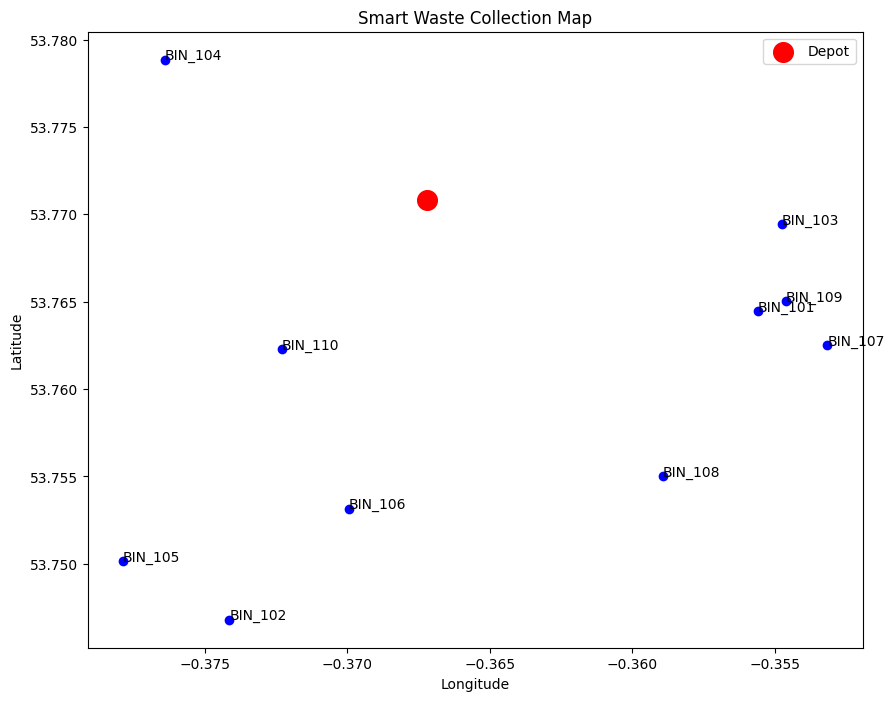

In [223]:
plt.figure(figsize=(10,8))

# Plot depot
plt.scatter(DEPOT[1], DEPOT[0], color='red', s=200, label='Depot')

# Plot bins
for b in reports:
    plt.scatter(b["coordinates"][1], b["coordinates"][0], color='blue')
    plt.text(b["coordinates"][1], b["coordinates"][0], b["bin_id"])

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Smart Waste Collection Map")
plt.legend()
plt.show()


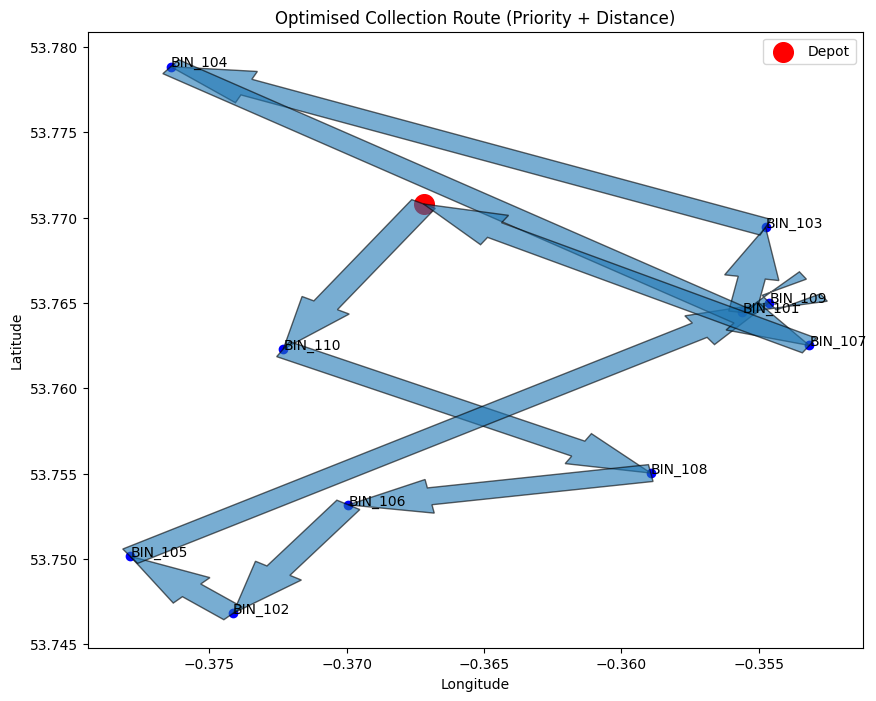

In [224]:
plt.figure(figsize=(10,8))

# Plot depot
plt.scatter(DEPOT[1], DEPOT[0], color='red', s=200, label='Depot')

# Plot bins
for b in reports:
    plt.scatter(b["coordinates"][1], b["coordinates"][0], color='blue')
    plt.text(b["coordinates"][1], b["coordinates"][0], b["bin_id"])

# Draw route path
current = DEPOT
for b in route:
    plt.arrow(current[1], current[0],
              b["coordinates"][1] - current[1],
              b["coordinates"][0] - current[0],
              length_includes_head=True,
              head_width=0.002,
              alpha=0.6)
    current = b["coordinates"]

# Return to depot
plt.arrow(current[1], current[0],
          DEPOT[1] - current[1],
          DEPOT[0] - current[0],
          length_includes_head=True,
          head_width=0.002,
          alpha=0.6)

plt.title("Optimised Collection Route (Priority + Distance)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


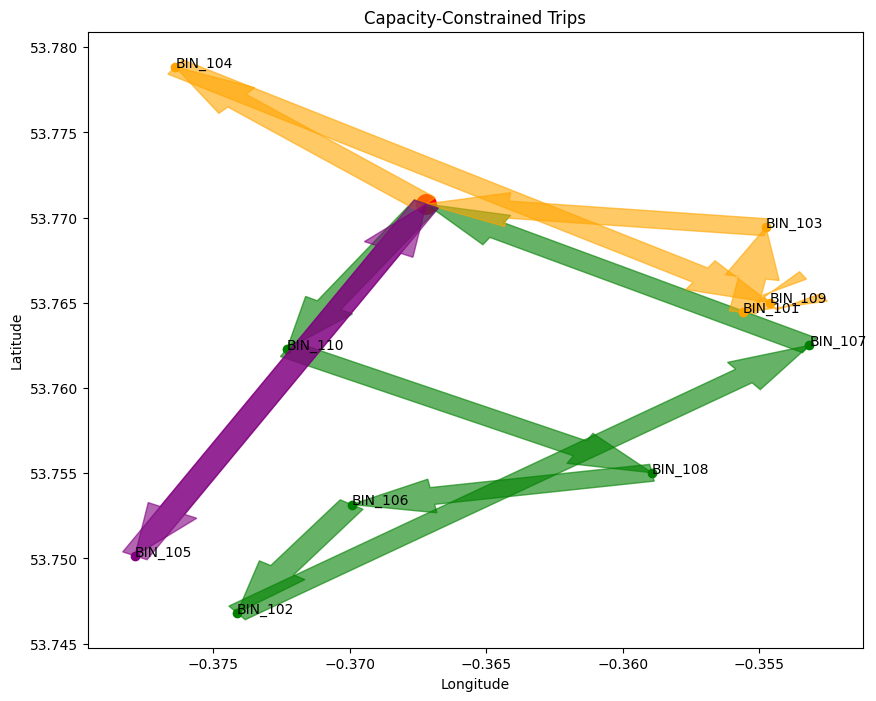

In [225]:
colors = ['green', 'orange', 'purple']

plt.figure(figsize=(10,8))

plt.scatter(DEPOT[1], DEPOT[0], color='red', s=200, label='Depot')

for i, trip in enumerate(all_trips):
    current = DEPOT
    
    for b in trip["bins"]:
        plt.scatter(b["coordinates"][1], b["coordinates"][0], color=colors[i])
        plt.text(b["coordinates"][1], b["coordinates"][0], b["bin_id"])
        
        plt.arrow(current[1], current[0],
                  b["coordinates"][1] - current[1],
                  b["coordinates"][0] - current[0],
                  length_includes_head=True,
                  head_width=0.002,
                  alpha=0.6,
                  color=colors[i])
        
        current = b["coordinates"]
    
    # return to depot
    plt.arrow(current[1], current[0],
              DEPOT[1] - current[1],
              DEPOT[0] - current[0],
              length_includes_head=True,
              head_width=0.002,
              alpha=0.6,
              color=colors[i])

plt.title("Capacity-Constrained Trips")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [226]:
def compute_priority_only_distance(reports, depot):
    ordered = sorted(reports, key=lambda x: x["priority_score"], reverse=True)
    current = depot
    total = 0
    
    for b in ordered:
        total += haversine(current, b["coordinates"])
        current = b["coordinates"]
        
    total += haversine(current, depot)
    return total


def compute_priority_distance_route(reports, depot):
    remaining = reports.copy()
    current = depot
    total = 0
    
    while remaining:
        scored = []
        for b in remaining:
            dist = haversine(current, b["coordinates"])
            score = dist / (b["priority_score"] + 0.01)
            scored.append((score, dist, b))
        
        scored.sort(key=lambda x: x[0])
        _, dist, chosen = scored[0]
        
        total += dist
        current = chosen["coordinates"]
        remaining.remove(chosen)
    
    total += haversine(current, depot)
    return total


In [227]:

priority_only_results = []
priority_distance_results = []
improvements = []

for i in range(10):
    
    random.seed(i)
    np.random.seed(i)
    
    # regenerate bins
    bins = [f"BIN_{100+j}" for j in range(10)]
    results = []
    
    for b in bins:
        img_path = random.choice(image_paths)
        results.append(process_bin(b, img_path))
    
    # assign coordinates
    for r in results:
        base = sector_coords[r["location"]]
        r["coordinates"] = (
            base[0] + random.uniform(-0.01, 0.01),
            base[1] + random.uniform(-0.01, 0.01)
        )
    
    po = compute_priority_only_distance(results, DEPOT)
    pd = compute_priority_distance_route(results, DEPOT)
    
    priority_only_results.append(po)
    priority_distance_results.append(pd)
    improvements.append((po - pd) / po * 100)


1/1 [==============================] - 0s 136ms/step


In [228]:
print("Priority-only Mean Distance:", round(np.mean(priority_only_results),2))
print("Priority+Distance Mean Distance:", round(np.mean(priority_distance_results),2))
print("Average % Improvement:", round(np.mean(improvements),2))
print("Std Dev Improvement:", round(np.std(improvements),2))


Priority-only Mean Distance: 18.18
Priority+Distance Mean Distance: 12.57
Average % Improvement: 30.02
Std Dev Improvement: 9.36


In [229]:
def real_time_simulation_with_collection(steps=5, collect_top_k=3):

    current_bins = results.copy()

    for t in range(steps):
        print(f"\n===== TIME STEP {t+1} =====")

        # 1) Waste accumulation
        for b in current_bins:
            growth = random.uniform(1, 5)
            b["fill_level"] = min(100, b["fill_level"] + growth)

            predicted = predict_future_fill(
                current_fill=b["fill_level"],
                hour=(datetime.datetime.now().hour + t) % 24,
                day=0,
                weekend=0
            )
            b["predicted_fill"] = round(predicted, 1)

            priority, _ = calculate_priority_score(b["confidence"], b)
            b["priority_score"] = priority

        # 2) Sort priorities
        current_bins = sorted(current_bins, key=lambda x: x["priority_score"], reverse=True)

        # 3) Show Top bins
        print("\nTop 3 Priority Bins:")
        for b in current_bins[:3]:
            print(f"{b['bin_id']} | Fill={round(b['fill_level'],1)}% | Pred={b['predicted_fill']}% | Priority={b['priority_score']}")

        # 4) Critical alerts
        critical_bins = [b for b in current_bins if b["fill_level"] >= 90]
        if critical_bins:
            print("\n⚠ CRITICAL ALERT:")
            for b in critical_bins:
                print(f"{b['bin_id']} has exceeded 90% capacity!")

        # 5) Simulate collection of top-k bins (empty them)
        print(f"\n🚛 Collecting top {collect_top_k} bins...")
        for b in current_bins[:collect_top_k]:
            b["fill_level"] = random.uniform(0, 15)  # emptied
            b["last_collection_hours"] = 0

        # Increment collection hours for all others
        for b in current_bins[collect_top_k:]:
            b["last_collection_hours"] += 1


In [230]:
real_time_simulation_with_collection(steps=5, collect_top_k=3)



===== TIME STEP 1 =====

Top 3 Priority Bins:
BIN_107 | Fill=86.8% | Pred=94.3% | Priority=0.75
BIN_100 | Fill=89.5% | Pred=91.4% | Priority=0.57
BIN_102 | Fill=77.0% | Pred=62.1% | Priority=0.56

🚛 Collecting top 3 bins...

===== TIME STEP 2 =====

Top 3 Priority Bins:
BIN_104 | Fill=65.1% | Pred=37.2% | Priority=0.48
BIN_103 | Fill=59.7% | Pred=32.4% | Priority=0.42
BIN_109 | Fill=70.8% | Pred=41.0% | Priority=0.38

🚛 Collecting top 3 bins...

===== TIME STEP 3 =====

Top 3 Priority Bins:
BIN_105 | Fill=72.4% | Pred=53.8% | Priority=0.37
BIN_108 | Fill=33.4% | Pred=41.5% | Priority=0.32
BIN_101 | Fill=43.3% | Pred=51.0% | Priority=0.28

🚛 Collecting top 3 bins...

===== TIME STEP 4 =====

Top 3 Priority Bins:
BIN_106 | Fill=24.6% | Pred=29.6% | Priority=0.26
BIN_109 | Fill=12.5% | Pred=19.1% | Priority=0.18
BIN_100 | Fill=22.8% | Pred=30.1% | Priority=0.17

🚛 Collecting top 3 bins...

===== TIME STEP 5 =====

Top 3 Priority Bins:
BIN_102 | Fill=24.5% | Pred=13.1% | Priority=0.16
BIN

In [232]:
data_rows = []

for bin_id in range(1, 51):  # 50 bins history
    fill = random.randint(5, 30)
    growth_rate = random.uniform(0.2, 1.8)  # each bin behaves differently

    for hour in range(0, 168):  # 7 days hourly
        hour_of_day = hour % 24
        day = hour // 24
        weekend = 1 if day in [5, 6] else 0

        # growth pattern (weekday/weekend + daily cycle)
        base_growth = growth_rate + (0.6 if weekend else 0.2)
        daily_cycle = 0.5 * np.sin(2 * np.pi * hour_of_day / 24)
        noise = random.uniform(-1.5, 1.5)

        fill = fill + base_growth + daily_cycle + noise
        fill = max(0, min(100, fill))

        # random collection event (bin emptied)
        if random.random() < 0.03:  # 3% chance per hour
            fill = random.uniform(0, 15)

        # target: 6 hours ahead
        future_fill = fill + 6 * base_growth + random.uniform(-3, 3)
        future_fill = max(0, min(100, future_fill))

        data_rows.append([fill, hour_of_day, day, weekend, future_fill])

import pandas as pd
df = pd.DataFrame(data_rows, columns=["fill_level","hour_of_day","day","weekend","future_fill"])

X = df[["fill_level","hour_of_day","day","weekend"]]
y = df["future_fill"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

forecast_model = RandomForestRegressor(n_estimators=200, random_state=42)
forecast_model.fit(X_train, y_train)

preds = forecast_model.predict(X_test)
print("Forecast MAE:", round(mean_absolute_error(y_test, preds),2))
print("Forecast R2:", round(r2_score(y_test, preds),2))


Forecast MAE: 2.59
Forecast R2: 0.98
